# 02 — Exploratory Data Analysis (EDA)

This notebook focuses on exploring the cleaned streaming platform datasets to understand content characteristics, identify data patterns, and uncover insights that may influence business decisions.

The analysis examines both **Movies** and **TV Shows** available across major streaming platforms, including Netflix, Hulu, Prime Video, and Disney+. Through exploratory data analysis, we will evaluate dataset structure, content distribution, platform trends, and key performance indicators.

The analysis includes:
- Reviewing dataset structure, missing values, and duplicates
- Summarizing key statistics and content distributions
- Visualizing trends using matplotlib
- Exploring relationships between platforms, genres, ratings, and release years

**Datasets**
- `MoviesOnStreamingPlatforms_Cleaned.csv`
- `TVShowsOnStreamingPlatforms_Cleaned.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

DATA_DIR = Path("/Users/veronicahuang/Desktop/streaming-bi-template/Data")

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"



## 1. Load the Cleaned Datasets


In [2]:
movies = pd.read_csv(MOVIES_PATH)
tv     = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:    ", tv.shape)

movies.head()

Movies shape: (9515, 19)
TV shape:     (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,THE IRISHMAN
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,DANGAL
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,DAVID ATTENBOROUGH: A LIFE ON OUR PLANET
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,94.0,7.0,0,LAGAAN: ONCE UPON A TIME IN INDIA
4,5,Roma,2018,18+,94/100,1,0,0,0,movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,94.0,18.0,0,ROMA



## 2. Quick Dataset Overview


In [3]:
def quick_overview(df: pd.DataFrame, name: str):
    print(f"=== {name} ===")
    display(df.head(3))
    print("\nColumns & dtypes:")
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}))
    print("\nMissing values (top 20):")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing.head(20).to_frame("missing_count"))
    print("\nInfo:")
    df.info()

quick_overview(movies, "Movies")

=== Movies ===


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,THE IRISHMAN
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,DANGAL
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,DAVID ATTENBOROUGH: A LIFE ON OUR PLANET



Columns & dtypes:


,column,dtype
ID,ID,int64
Title,Title,str
Year,Year,int64
Age,Age,str
Rotten Tomatoes,Rotten Tomatoes,str
Netflix,Netflix,int64
Hulu,Hulu,int64
Prime Video,Prime Video,int64
Disney+,Disney+,int64
Type,Type,str



Missing values (top 20):


,missing_count
ID,0
Genre,0
Type_raw,0
Age_Min,0
RottenTomatoes_Score,0
IMDb_ID,0
IMDb,0
Language,0
Country,0
Type,0



Info:
<class 'pandas.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    9515 non-null   int64  
 1   Title                 9515 non-null   str    
 2   Year                  9515 non-null   int64  
 3   Age                   9515 non-null   str    
 4   Rotten Tomatoes       9515 non-null   str    
 5   Netflix               9515 non-null   int64  
 6   Hulu                  9515 non-null   int64  
 7   Prime Video           9515 non-null   int64  
 8   Disney+               9515 non-null   int64  
 9   Type                  9515 non-null   str    
 10  Genre                 9515 non-null   str    
 11  Country               9515 non-null   str    
 12  Language              9515 non-null   str    
 13  IMDb                  9515 non-null   float64
 14  IMDb_ID               9515 non-null   str    
 15  RottenTomatoes_Score  951

In [4]:
quick_overview(tv, "TV Shows")

=== TV Shows ===


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,Breaking Bad,2008,18+,100/100,1,0,0,0,tv_show,"crime television series, drama television seri...",United States,"American English, Spanish language in the Amer...",10.0,tt0903747,100,18.0,1,BREAKING BAD
1,2,Stranger Things,2016,16+,96/100,1,0,0,0,tv_show,"science fiction television program, horror tel...",United States,English,9.0,tt4574334,96,16.0,1,STRANGER THINGS
2,3,Attack on Titan,2013,18+,95/100,1,1,0,0,tv_show,reality television,United States,English,9.0/10,tt0092400,95,18.0,1,ATTACK ON TITAN



Columns & dtypes:


,column,dtype
ID,ID,int64
Title,Title,str
Year,Year,int64
Age,Age,str
Rotten Tomatoes,Rotten Tomatoes,str
Netflix,Netflix,int64
Hulu,Hulu,int64
Prime Video,Prime Video,int64
Disney+,Disney+,int64
Type,Type,str



Missing values (top 20):


,missing_count
ID,0
Genre,0
Type_raw,0
Age_Min,0
RottenTomatoes_Score,0
IMDb_ID,0
IMDb,0
Language,0
Country,0
Type,0



Info:
<class 'pandas.DataFrame'>
RangeIndex: 5368 entries, 0 to 5367
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5368 non-null   int64  
 1   Title                 5368 non-null   str    
 2   Year                  5368 non-null   int64  
 3   Age                   5368 non-null   str    
 4   Rotten Tomatoes       5368 non-null   str    
 5   Netflix               5368 non-null   int64  
 6   Hulu                  5368 non-null   int64  
 7   Prime Video           5368 non-null   int64  
 8   Disney+               5368 non-null   int64  
 9   Type                  5368 non-null   str    
 10  Genre                 5368 non-null   str    
 11  Country               5368 non-null   str    
 12  Language              5368 non-null   str    
 13  IMDb                  5368 non-null   str    
 14  IMDb_ID               5368 non-null   str    
 15  RottenTomatoes_Score  536


## 3. Data Quality Checks


In [6]:
def data_quality_checks(df: pd.DataFrame, name: str, subset_for_dupes=None):
    print(f"=== {name} quality checks ===")

    # Duplicates
    if subset_for_dupes is None:
        dup_count = df.duplicated().sum()
        print("Exact duplicate rows:", int(dup_count))
    else:
        dup_count = df.duplicated(subset=subset_for_dupes).sum()
        print(f"Duplicates based on {subset_for_dupes}:", int(dup_count))

    # Show sample duplicates if any
    if dup_count > 0:
        if subset_for_dupes is None:
            dup_rows = df[df.duplicated(keep=False)].head(10)
        else:
            dup_rows = df[df.duplicated(subset=subset_for_dupes, keep=False)].sort_values(subset_for_dupes).head(10)
        display(dup_rows)

    # Numeric summary
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    print("\nNumeric columns:", numeric_cols[:20], "..." if len(numeric_cols) > 20 else "")
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))

    print("\nDone.\n")

subset_movies = [c for c in ['Title', 'Year'] if c and c in movies.columns]
subset_tv     = [c for c in ['Title', 'Year'] if c and c in tv.columns]

data_quality_checks(movies, "Movies", subset_for_dupes=subset_movies if subset_movies else None)
data_quality_checks(tv, "TV Shows", subset_for_dupes=subset_tv if subset_tv else None)

=== Movies quality checks ===
Duplicates based on ['Title', 'Year']: 0

Numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'IMDb', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw'] 


,count,mean,std,min,25%,50%,75%,max
ID,9515.0,4758.000000,2746.888239,1.0,2379.5,4758.0,7136.5,9515.0
Year,9515.0,2007.422386,19.130367,1914.0,2006.0,2015.0,2018.0,2021.0
Netflix,9515.0,0.388334,0.487397,0.0,0.0,0.0,1.0,1.0
Hulu,9515.0,0.110037,0.312952,0.0,0.0,0.0,0.0,1.0
Prime Video,9515.0,0.432265,0.495417,0.0,0.0,0.0,1.0,1.0
Disney+,9515.0,0.096900,0.295837,0.0,0.0,0.0,0.0,1.0
IMDb,9515.0,6.720494,1.815770,1.0,6.0,7.0,7.3,10.0
RottenTomatoes_Score,9515.0,53.543878,13.192884,10.0,44.0,52.0,62.0,98.0
Age_Min,9515.0,15.132738,3.229361,7.0,16.0,16.0,16.0,18.0
Type_raw,9515.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0



Done.

=== TV Shows quality checks ===
Duplicates based on ['Title', 'Year']: 0

Numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw'] 


,count,mean,std,min,25%,50%,75%,max
ID,5368.0,2814.945790,1672.385727,1.0,1345.75,2788.0,4308.25,5717.0
Year,5368.0,2012.628726,10.142813,1904.0,2011.00,2016.0,2018.00,2021.0
Netflix,5368.0,0.367176,0.482080,0.0,0.00,0.0,1.00,1.0
Hulu,5368.0,0.301975,0.459157,0.0,0.00,0.0,1.00,1.0
Prime Video,5368.0,0.341095,0.474122,0.0,0.00,0.0,1.00,1.0
Disney+,5368.0,0.065387,0.247231,0.0,0.00,0.0,0.00,1.0
RottenTomatoes_Score,5368.0,47.220380,19.555753,10.0,36.00,48.0,60.00,100.0
Age_Min,5368.0,14.919896,3.467906,7.0,16.00,16.0,16.00,18.0
Type_raw,5368.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0



Done.



## 4. Descriptive statistics

In [7]:
display(movies.describe(include=[np.number]).T.head(30))

,count,mean,std,min,25%,50%,75%,max
ID,9515.0,4758.000000,2746.888239,1.0,2379.5,4758.0,7136.5,9515.0
Year,9515.0,2007.422386,19.130367,1914.0,2006.0,2015.0,2018.0,2021.0
Netflix,9515.0,0.388334,0.487397,0.0,0.0,0.0,1.0,1.0
Hulu,9515.0,0.110037,0.312952,0.0,0.0,0.0,0.0,1.0
Prime Video,9515.0,0.432265,0.495417,0.0,0.0,0.0,1.0,1.0
Disney+,9515.0,0.096900,0.295837,0.0,0.0,0.0,0.0,1.0
IMDb,9515.0,6.720494,1.815770,1.0,6.0,7.0,7.3,10.0
RottenTomatoes_Score,9515.0,53.543878,13.192884,10.0,44.0,52.0,62.0,98.0
Age_Min,9515.0,15.132738,3.229361,7.0,16.0,16.0,16.0,18.0
Type_raw,9515.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [8]:
# Categorical summary
display(movies.describe(include=["object"]).T.head(30))

/var/folders/md/c9b0dgp518v76y7l9g2rzr9m0000gn/T/ipykernel_22318/1990252109.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(movies.describe(include=["object"]).T.head(30))


,count,unique,top,freq
Title,9515,9515,The Irishman,1
Age,9515,5,18+,6453
Rotten Tomatoes,9515,85,44/100,318
Type,9515,1,movie,9515
Genre,9515,2017,drama film,3994
Country,9515,582,United States,6271
Language,9515,426,English,7296
IMDb_ID,9515,6773,tt0245844,2730
Title_key,9515,9515,THE IRISHMAN,1


In [9]:
display(movies.describe())

,ID,Year,Netflix,Hulu,Prime Video,Disney+,IMDb,RottenTomatoes_Score,Age_Min,Type_raw
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.0
mean,4758.000000,2007.422386,0.388334,0.110037,0.432265,0.096900,6.720494,53.543878,15.132738,0.0
std,2746.888239,19.130367,0.487397,0.312952,0.495417,0.295837,1.815770,13.192884,3.229361,0.0
min,1.000000,1914.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,7.000000,0.0
25%,2379.500000,2006.000000,0.000000,0.000000,0.000000,0.000000,6.000000,44.000000,16.000000,0.0
50%,4758.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,7.000000,52.000000,16.000000,0.0
75%,7136.500000,2018.000000,1.000000,0.000000,1.000000,0.000000,7.300000,62.000000,16.000000,0.0
max,9515.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,10.000000,98.000000,18.000000,0.0



## 5. Creating Exploratory Plots


In [17]:
# Choose a dataset
df = movies

# Explore columns to decide what to plot
df.columns

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre',
       'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key'],
      dtype='str')

In [18]:
MOVIES_YEAR_COL   = 'Year'
MOVIES_GENRE_COL  = 'Genre'
MOVIES_RATING_COL = 'IMDb'
MOVIES_COUNTRY_COL = 'Country'
MOVIES_PLATFORM_COLS = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

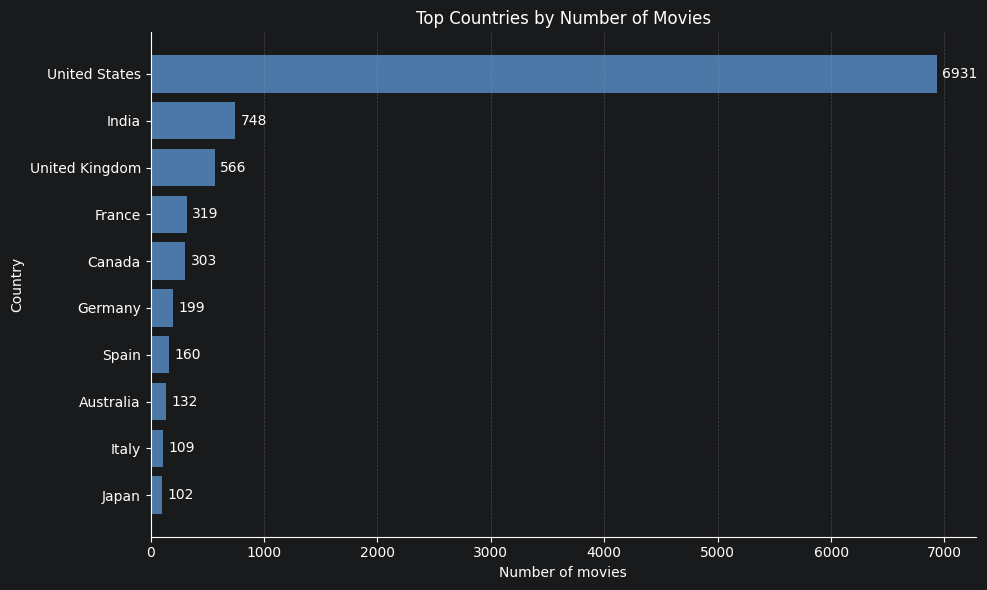

In [27]:
#1 ) Bar chart: Top Countries by Number of Movies
if 'movies' not in globals():
    movies = pd.read_csv(MOVIES_PATH)

top_countries = (
    movies[MOVIES_COUNTRY_COL]
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index, top_countries.values, color='#4C78A8')

ax.bar_label(bars, padding=4)
ax.set_title('Top Countries by Number of Movies')
ax.set_xlabel('Number of movies')
ax.set_ylabel('Country')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

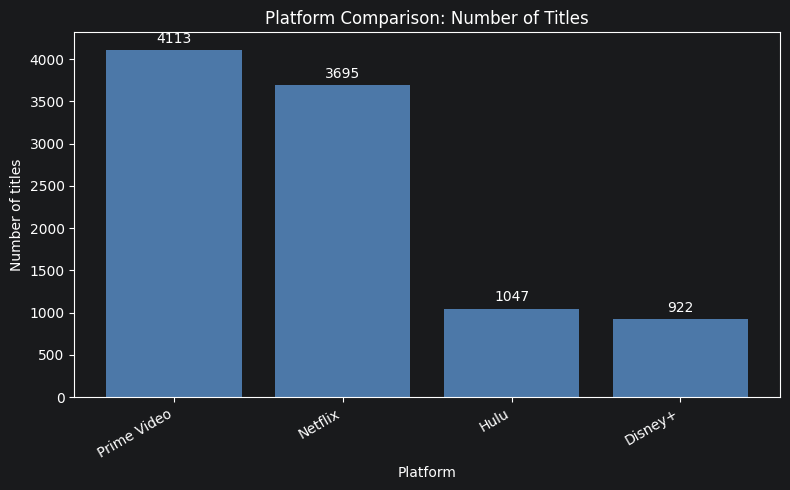

In [21]:
#2 ) Bar chart: Platform Comparison by the Number of Titles of Movies
candidate_platform_cols = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platform_cols = [col for col in candidate_platform_cols if col in df.columns]

if platform_cols:
    platform_totals = df[platform_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(platform_totals.index, platform_totals.values, color='#4C78A8')
    plt.bar_label(bars, padding=3)
    plt.title('Platform Comparison: Number of Titles')
    plt.xlabel('Platform')
    plt.ylabel('Number of titles')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No platform indicator columns found. Expected one or more of:', candidate_platform_cols)

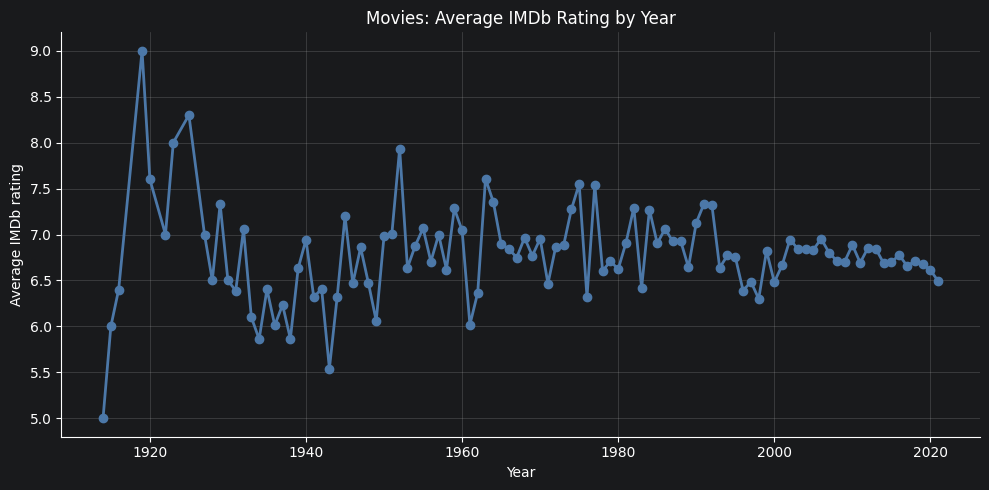

In [26]:
#3 ) Line chart: Average IMDb Rating by Year
if 'movies' not in globals():
    movies = pd.read_csv(MOVIES_PATH)

movies_by_year = movies[[MOVIES_YEAR_COL, MOVIES_RATING_COL]].copy()
movies_by_year[MOVIES_YEAR_COL] = pd.to_numeric(movies_by_year[MOVIES_YEAR_COL], errors='coerce')
movies_by_year[MOVIES_RATING_COL] = pd.to_numeric(movies_by_year[MOVIES_RATING_COL], errors='coerce')
movies_by_year = movies_by_year.dropna()
movies_by_year[MOVIES_YEAR_COL] = movies_by_year[MOVIES_YEAR_COL].astype(int)

avg_imdb_by_year = movies_by_year.groupby(MOVIES_YEAR_COL)[MOVIES_RATING_COL].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_imdb_by_year.index, avg_imdb_by_year.values, marker='o', linewidth=2, color='#4C78A8')

ax.set_title('Movies: Average IMDb Rating by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average IMDb rating')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

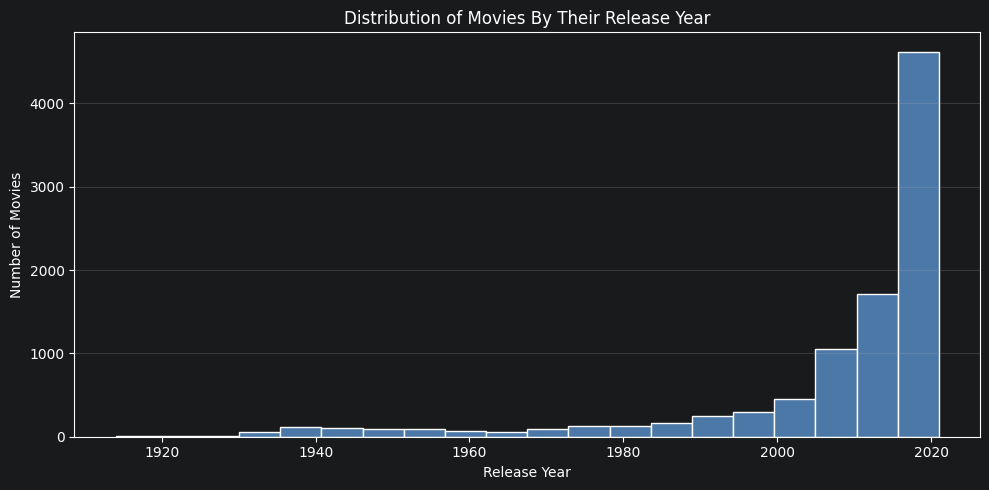

In [31]:
#4 ) Histogram: Distribution of Movies by their Release Year
if 'movies' not in globals():
    movies = pd.read_csv(MOVIES_PATH)

release_years = pd.to_numeric(movies[MOVIES_YEAR_COL], errors='coerce').dropna().astype(int)

plt.figure(figsize=(10, 5))
plt.hist(release_years, bins=20, color='#4C78A8', edgecolor='white')
plt.title('Distribution of Movies By Their Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()